# Nonparametric Statistics
In parametric statistics we discuss various statistical tests based on the assumption that the samples involved are drawn from normal populations. However, there are many situations where we know little about the shape of the population distribution from which the samples are drawn, and in such cases the assumption of normality may be hazardous. Furthemore, if the data are extremely nonnormal, the t-tests and F-test are invalid. Fortunately, there is a class of statistical tests that are valid for samples from continuous population distributions of any shape. These are called **nonparametric tests**, and they are based on order statistics. Nonparametric procedures are often (perhaps more accurately) called distribution-free statistics.<br>

In this notebook, we consider several of the simplest and most widely used of these tests. Throughout this notebook, we assume that the random variable of interest is a continuous random variable and the scale of measurement is at least ordinal.  The techniques presented here can be used when the data are interval and the required condition of normality is unsatisfied. In such circumstances, we will treat the interval data as if they were ordinal. For this reason, even when the data are interval and the mean is the appropriate measure of location, we will choose instead to test population locations.


In [1]:
import pandas as pd
from pandas import DataFrame
import numpy as np
from scipy.stats import t, chi2, norm, f, binom
from math import sqrt

# For data visualization
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

## One-Sample Test
### Sign Test

#### Example - Job completion time
A manager of a manufacturing company is interested in finding the median time taken by company technicians to complete a job.
The manager takes a sample of 10 technicians and observes the time (in minutes) taken to complete the job, as follows.<br>
Test at the 5% level of significance that the median time taken by the company technician to complete a job is 45 minutes.

In [149]:
data = [42, 40, 46, 44, 43, 48, 41, 42, 42, 44]
n = len(data)

**Solution**: In this example, we wish to test the hypothesis<br>
H0: M = 45<br>
H1: M ≠ 45

In [142]:
grater_than_45 = [1 if i>45 else 0 for i in data]
grater_than_45

[0, 0, 1, 0, 0, 1, 0, 0, 0, 0]

In [153]:
# r is our test statistics
r = sum(grater_than_45)
p_value = 2 * binom.cdf(r, n=n, p=0.5)
round(p_value,2)

0.11

So the p-value for this test is 0.11 > α = 0.05. We do not reject the null hypothesis.<br>
**Note**: For large sample size n, we could use the normal approximation to the binomial.

### The Wilcoxon Signed-Rank Test
Occasionally, we have a random sample that has been sampled from a population known
to be symmetric about the unknown median, and the scale of measurement is at least
interval. In such cases, the simple sign test discussed in the previous section is not very desirable
because it does not use all the information available in the sample. A more powerful test is
the **Wilcoxon signed-rank test**. Since the sampled population is assumed to be symmetric,
any conclusions made about the median are also valid for the mean.

#### Example 14.2.3 (Bond strength of materials) 
An article in Annual Reviews of Material
Research 2001 (p. 291) presents bond strengths for various energetic materials (explosives,
propellants, and pyrotechnics). The bond strengths M for 15 such materials are shown
below. (M = 220 is an industrial standard). Test at the 5% level of significance that the median
bond strength has value 220.

**Solution**: The hypothesis that we would like to test is<br>
**H0**: M = 220<br>
**H1**: M ≠ 220

In [163]:
data = [323, 312, 300, 284, 283, 261, 207, 183, 180, 179, 174, 167, 167, 157, 120]
data = pd.DataFrame(data, columns=['Strength'])
data['di'] = data['Strength'] - 220
data['|di|'] = data['di'].abs()
data['rank'] = data['|di|'].rank()

below_mean_rank = data[data['di']<0]['rank'].sum()
above_mean_rank = data[data['di']>0]['rank'].sum()

below_mean_rank, above_mean_rank


(55.0, 65.0)

In [164]:
test_stat = min(below_mean_rank, above_mean_rank)
test_stat

55.0

For the sample size 15, the value from Table A.10 indicates that we reject H0 at significance level α = 0.05 if the test statistic is less than or equal to 25.<br>
In this example, the test statistics has the value 55 > 25, so we do not reject the null hypothesis. Based on these data, we may conclude that the median bond strength of various energetic materials is not different from 220.

## Independent Samples Tests
### Wilcoxon Rank Sum Test
The test we introduce in this section deals with problems with the following characteristics:
1. The problem objective is to compare two populations.
2. The data are either ordinal or interval where the normality requirement necessary to perform the equal-variances t-test of μ1 − μ2 is unsatisfied.
3. The samples are independent.

To illustrate how to compute the test statistic for the Wilcoxon Rank Sum Test for independent samples, we offer the following example.


#### Example - Wilcoxon Rank Sum Test
Suppose that we want to determine whether the following observations drawn from two populations allow us to conclude at the 5% significance level that the location of population 1 is to the left of the location of population 2.<br>
Sample 1: 22 23 20<br>
Sample 2: 18 27 26<br>

We want to test the following hypotheses:<br>
`H0: The two population locations are the same.`<br>
`H1: The location of population 1 is to the left of the location of population 2`.

**Solution**<br>
The first step is to rank all six observations, with rank 1 assigned to the smallest observation and rank 6 to the largest.
<center><img src="Images/NonParametric Tests/1.png" width=450></center>

It is possible to derive the sampling distribution of the test statistic for any other sample sizes, the process can be quite tedious. Fortunately it is also unnecessary. Statisticians have shown that when the sample sizes are larger than 10, the test statistic is approximately normally distributed with mean E(T ) and standard deviation σT where
<center><img src="Images/NonParametric Tests/2.png" width=350></center>

#### Example - Wilcoxon Rank Sum Test for Ordinal Data 
**Comparing Pharmaceutical Painkillers**<br>
A pharmaceutical company is planning to introduce a new painkiller. In a preliminary experiment to determine its effectiveness, 30 people were randomly selected, of whom 15 were given the new painkiller and 15 were given aspirin. All 30 were told to use the drug when headaches or other minor pains occurred and to indicate which of the following statements most accurately represented the effectiveness of the drug they took:<br>
5 = The drug was extremely effective.<br>
4 = The drug was quite effective.<br>
3 = The drug was somewhat effective.<br>
2 = The drug was slightly effective.<br>
1 = The drug was not at all effective.<br>
The responses are listed here using the codes. Can we conclude at the 5% significance level that the new painkiller is perceived to be more effective?<br>

New painkiller: 3, 5, 4, 3, 2, 5, 1, 4, 5, 3, 3, 5, 5, 5, 4<br>
Aspirin: 4, 1, 3, 2, 4, 1, 3, 4, 2, 2, 2, 4, 3, 4, 5<br>

**Solution**<br>
**H0**: The two population locations are the same.<br>
**H1**: The location of population 1(new painkiller) is to the right of the location of population 2(aspirin).


In [8]:
new = [3, 5, 4, 3, 2, 5, 1, 4, 5, 3, 3, 5, 5, 5, 4]
aspirin = [4, 1, 3, 2, 4, 1, 3, 4, 2, 2, 2, 4, 3, 4, 5]

df = pd.DataFrame(new+aspirin, columns=['Opinion']).sort_values(by='Opinion', ignore_index=True).reset_index()
df['index'] = df['index'] + 1
g = df.groupby('Opinion').mean().round(2)
g

,index
Opinion,
1,2.0
2,6.0
3,12.0
4,19.5
5,27.0


In [9]:
new_rank = [g.iloc[i-1,0] for i in new]
aspirin_rank = [g.iloc[i-1,0] for i in aspirin]

data = pd.DataFrame({'New':new, 'New_rank':new_rank, 'Aspirin':aspirin, 'Aspirin_rank':aspirin_rank})
data

,New,New_rank,Aspirin,Aspirin_rank
0,3,12.0,4,19.5
1,5,27.0,1,2.0
2,4,19.5,3,12.0
3,3,12.0,2,6.0
4,2,6.0,4,19.5
5,5,27.0,1,2.0
6,1,2.0,3,12.0
7,4,19.5,4,19.5
8,5,27.0,2,6.0
9,3,12.0,2,6.0


In [4]:
t1 = data['New_rank'].sum()
t2 = data['Aspirin_rank'].sum()
t1, t2

(276.5, 188.5)

In [5]:
n1 = len(new)
n2 = len(aspirin)

e = n1 * (n1 + n2 + 1) / 2
sigma = sqrt(n1 * n2 * (n1 + n2 + 1) / 12)

z = (t1 - e) / sigma
z

1.8250349827255485

In [7]:
p_value = 1 - norm.cdf(z)
p_value

0.0339978752175345

Because p_value is smaller than the level of significance, we reject the null hypothesis in favor of alternetive hypothesis and conclude that the new painkiller is percieved as more effective than Aspirin.

#### Example - Wilcoxon Rank Sum Test for Interval Data
**Retaining Workers**<br>
Because of the high cost of hiring and training new employees, employers would like to ensure that they retain highly qualified workers. To help develop a hiring program, the human resources manager of a large company wanted to compare how long business and nonbusiness university graduates worked for the company before quitting to accept a position elsewhere. The manager selected a random sample of 25 business and 20 nonbusiness graduates who had been hired 5 years ago. The number of months each had worked for the company was recorded. (Those who had not quit were recorded as having worked for 60 months.) The data are listed below. Can the human resources manager conclude at the 5% significance level that a difference in duration of employment exists between business and nonbusiness graduates?

In [12]:
business = [60, 11, 18, 19, 5, 25, 60, 7, 8, 17, 37, 4, 8, 28, 27, 11, 60, 25, 5, 13, 22, 11, 17, 9, 4]
nonbusiness = [25, 60, 22, 24, 23, 36, 39, 15, 35, 16, 28, 9, 60, 29, 16, 22, 60, 17, 60, 32]

**Solution**<br>
The problem objective is to compare two populations whose data are interval. The samples are independent. Thus, the appropriate parametric technique is the t-test of μ1 − μ2, which requires that the populations be normally distributed. However, when the histograms are drawn, it becomes clear that this requirement is unsatisfied. It follows that the correct statistical procedure is the Wilcoxon Rank Sum Test. The null and alternative hypotheses are<br>

**H0**: The two population locations are the same.<br>
**H1**: The location of population 1 (business graduates) is different from the location of population 2 (nonbusiness graduates).

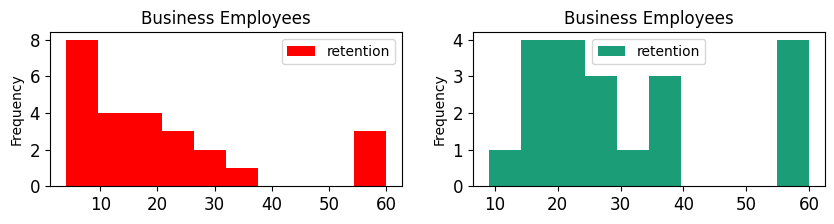

In [66]:
# Charts showcasing repeat calls by week and month

df_business = pd.DataFrame(business, columns=['retention'])
df_nonbusiness = pd.DataFrame(nonbusiness, columns=['retention'])

fig, ax = plt.subplots(1, 2)

df_business.plot(kind='hist', stacked=False, figsize=(10,2), linewidth=0, title='Business Employees', fontsize=12, colormap='hsv', ax=ax[0] )
df_nonbusiness.plot(kind='hist', stacked=False, figsize=(10,2), linewidth=0, title='Business Employees', fontsize=12, colormap='Dark2', ax=ax[1] )

plt.show()

In [67]:
alpha = 0.05
zl = norm.ppf(alpha/2)
zr = norm.ppf(1-alpha/2)
print(f"The acceptance region is: ({zl}, {zr})")

The acceptance region is: (-1.9599639845400545, 1.959963984540054)


In [68]:
df = pd.DataFrame(business+nonbusiness, columns=['retention']).sort_values(by='retention', ignore_index=True).reset_index()
df['index'] = df['index'] + 1
g = df.groupby('retention').mean().round(2)
g

,index
retention,
4,1.5
5,3.5
7,5.0
8,6.5
9,8.5
11,11.0
13,13.0
15,14.0
16,15.5


In [79]:
business_rank = pd.merge(left=df_business, right=g, on='retention')['index']
nonbusiness_rank = pd.merge(left=df_nonbusiness, right=g, on='retention')['index']

data_business = pd.DataFrame({'Business':business, 'rank':business_rank})
data_nonbusiness = pd.DataFrame({'NonBusiness':nonbusiness, 'rank':nonbusiness_rank})

data_nonbusiness


,NonBusiness,rank
0,25,28.0
1,60,42.0
2,22,23.0
3,24,26.0
4,23,25.0
5,36,36.0
6,39,38.0
7,15,14.0
8,35,35.0
9,16,15.5


In [84]:
t1 = data_business['rank'].sum()
t2 = data_nonbusiness['rank'].sum()
t = t1
t, t1, t2

(463.0, 463.0, 572.0)

In [85]:
n1 = len(business)
n2 = len(nonbusiness)

e = n1 * (n1 + n2 + 1) / 2
sigma = sqrt(n1 * n2 * (n1 + n2 + 1) / 12)

z = (t - e) / sigma
z

-2.55826027842632

In [88]:
p_value = 2 * norm.cdf(z)
p_value

0.010519732237395836

There is strong evidence to infer that the duration of employment is different for business and nonbusiness graduates. The data cannot tell us the cause of this conclusion. For example, we don’t know whether business graduates are in greater demand, making it more likely that such employees will leave for better jobs, or whether nonbusiness graduates are more satisfied with their jobs and thus remain longer. Moreover, we don’t know what the results would have been had we surveyed employees 10 years after they were employed.

## Matched Pair Tests
In this section, we discuss the nonparametric techniques for comparing two populations of data that are either ordinal or interval (nonnormal) and generated from a matched pairs experiment. We have dealt with this type of experiment in the "Inference Two Means" notebook, where we dealt with the mean of the paired differences represented by the parameter μD. In this
section, we introduce two nonparametric techniques that test hypotheses in problems with the following characteristics:
1. The problem objective is to compare two populations.
2. The data are either ordinal or interval (where the normality requirement necessary to perform the parametric test is unsatisfied).
3. The samples are matched pairs.

### Sign Test
The sign test is employed in the following situations:
1. The problem objective is to compare two populations.
2. The data are ordinal.
3. The experimental design is matched pairs.

We will arbitrarily choose the test statistic to be the number of positive differences, which we denote x. The test statistic x is a binomial random variable, and under the null hypothesis, the binomial proportion is p = .5. Thus, the sign test is none
other than the z-test of p.<br>
We know that x is binomially distributed and that, for sufficiently large n, x is approximately normally distributed with mean μ = np and standard deviation $\sqrt{np(1 − p)}$. Thus, the standardized test statistic is
<center><img src="Images/NonParametric Tests/3.png" width=150></center>

The null hypothesis<br>
**H0: The two population locations are the same**<br>
is equivalent to testing<br>
**H0: p = .5**<br>
Therefore, the test statistic, assuming that the null hypothesis is true, becomes
<center><img src="Images/NonParametric Tests/4.png" width=650></center>

#### Example - Comparing the Comfort of Two Midsize Cars
In an experiment to determine which of two cars is perceived to have the more comfortable ride, 25 people rode (separately) in the back seat of an expensive European model and also in the back seat of a North American midsize car. Each of the 25 people was asked to rate the ride on the following 5-point scale:<br>
1 = Ride is very uncomfortable.<br>
2 = Ride is quite uncomfortable.<br>
3 = Ride is neither uncomfortable nor comfortable.<br>
4 = Ride is quite comfortable.<br>
5 = Ride is very comfortable.<br>
The results are shown below. Do these data allow us to conclude at the 5% significance level that the European car is perceived to be more comfortable than the North American car?

In [98]:
euro = [3, 2, 5, 3, 2, 5, 2, 4, 4, 2, 2, 3, 2, 3, 2, 4, 5, 2, 5, 3, 4, 3, 3, 5, 5]
na = [4, 1, 4, 2, 1, 3, 3, 2, 2, 2, 1, 4, 1, 4, 1, 3, 4, 3, 4, 1, 2, 3, 4, 2, 3]


The problem objective is to compare two populations of ordinal data. Because the same 25 people rated both cars, we recognize the experimental design as matched pairs. The sign test is applied, with the following hypotheses:<br>
**H0**: The two population locations are the same.<br>
**H1**: The location of population 1 (European car rating) is to the right of the location of population 2 (North American car rating).

In [130]:
alpha = 0.05
threshold = norm.ppf(1-alpha)
threshold

1.6448536269514722

In [123]:
diffs = np.sign(np.subtract(euro, na))
positives = len([i for i in diffs if i>0])
negatives = len([i for i in diffs if i<0])
zeros = len([i for i in diffs if i==0])

positives, negatives, zeros

(17, 6, 2)

In [126]:
x = positives
n = positives + negatives
z = (x - 0.5 * n) / (0.5 * sqrt(n))
z

2.2936585546278225

In [129]:
p_value = 1 - norm.cdf(z)
p_value

0.010905059571861164

**Interpretation**: There is relatively strong evidence to indicate that people perceive the European car as providing a more comfortable ride than the North American car. There are, however, two aspects of the experiment that may detract from that conclusion. First, did the respondents know in which car they were riding? If so, they may have answered on their preconceived bias that European cars are more expensive and therefore better. If the subjects were blindfolded, we would be more secure in our conclusion. Second, was the order in which each subject rode the two cars varied? If all the subjects rode in the
North American car first and the European car second, that may have influenced their ratings. The experiment should have been conducted so that the car each subject rode in first was randomly determined.

#### Checking the Required Conditions
As we noted earlier, the sign test requires that the populations be identical in shape and spread. The histogram of the ratings for the European car suggests that the ratings may be uniformly distributed between 2 and 5. The histogram of the ratings for the North American car seems to indicate that the ratings are uniformly distributed between 1 and 4. Thus, both sets of ratings have the same shape and spread but their locations differ.<br>
The other condition is that the sample size exceeds 10, which is already satisfied.

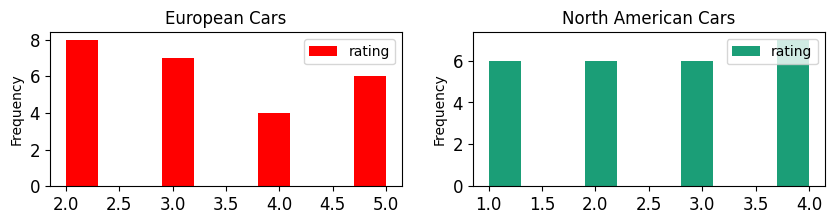

In [131]:
# Charts showcasing repeat calls by week and month

df_euro = pd.DataFrame(euro, columns=['rating'])
df_na = pd.DataFrame(na, columns=['rating'])

fig, ax = plt.subplots(1, 2)

df_euro.plot(kind='hist', stacked=False, figsize=(10,2), linewidth=0, title='European Cars', fontsize=12, colormap='hsv', ax=ax[0] )
df_na.plot(kind='hist', stacked=False, figsize=(10,2), linewidth=0, title='North American Cars', fontsize=12, colormap='Dark2', ax=ax[1] )

plt.show()

#### Example (Hemoglobin levels) 
Below, you see the hemoglobin (grams/100mL of blood) in 12 anemic rats before and after
four weeks of added iron in the diet (0.5 milligram per day). Test, at the 1% and 5% level
of significance, the hypothesis that the distribution of hemoglobin in anemic rats before
and after the treatment is the same. We assume here that the interval of four weeks is
sufficient to ensure that X (after) and X (before) are independent.



In [13]:
before = [3.4, 3.0, 3.0, 3.4, 3.7, 4.0, 2.9, 2.9, 3.1, 2.8, 2.8, 2.4]
after = [4.9, 2.3, 3.1, 2.1, 2.6, 3.8, 5.8, 7.9, 3.6, 4.1, 3.8, 3.3]

**Solution**<br>
**H0**: F1 = F2<br>
**H1**: F1 > F2

In [21]:
df = pd.DataFrame({'Before':before, 'After':after})
df['Diff'] = df['After'] - df['Before']
df['Sign'] = np.where(df['Diff']>0, 1, 0)
df

,Before,After,Diff,Sign
0,3.4,4.9,1.5,1
1,3.0,2.3,-0.7,0
2,3.0,3.1,0.1,1
3,3.4,2.1,-1.3,0
4,3.7,2.6,-1.1,0
5,4.0,3.8,-0.2,0
6,2.9,5.8,2.9,1
7,2.9,7.9,5.0,1
8,3.1,3.6,0.5,1
9,2.8,4.1,1.3,1


In [23]:
r = df['Sign'].sum()
r

8

In [25]:
n= len(before)
p_value = binom.cdf(r, n=n, p=0.5)
p_value

0.927001953125

In [31]:
binom.cdf(10, n=n, p=0.5) - binom.cdf(1, n=n, p=0.5)


0.99365234375

In [32]:
binom.cdf(9, n=n, p=0.5) - binom.cdf(2, n=n, p=0.5)


0.96142578125

Under H0 we have that P(2 ≤ R ≤ 10) > 0.99 and P(3 ≤ R ≤ 9) > 0.95. Thus, no matter whether we consider a one- or a
two-sided test, we do not have significance at either the 1% or 5% levels.<br>
If we had assumed normality in this example and used the paired t-test, then similarly we would have found that the value of the test statistic is t11 = 1.61, which is not significant at either the 1% or 5% level.<br>
The conclusion is that we cann't reject the null hypothesis and the two population locations are the same.

### Wilcoxon Signed Rank Sum Test